In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

print("téléchargement")
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
df = boston.frame

df['MEDV'] = pd.to_numeric(df['MEDV'])

print("5 premières lignes")
display(df.head())

téléchargement
5 premières lignes


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


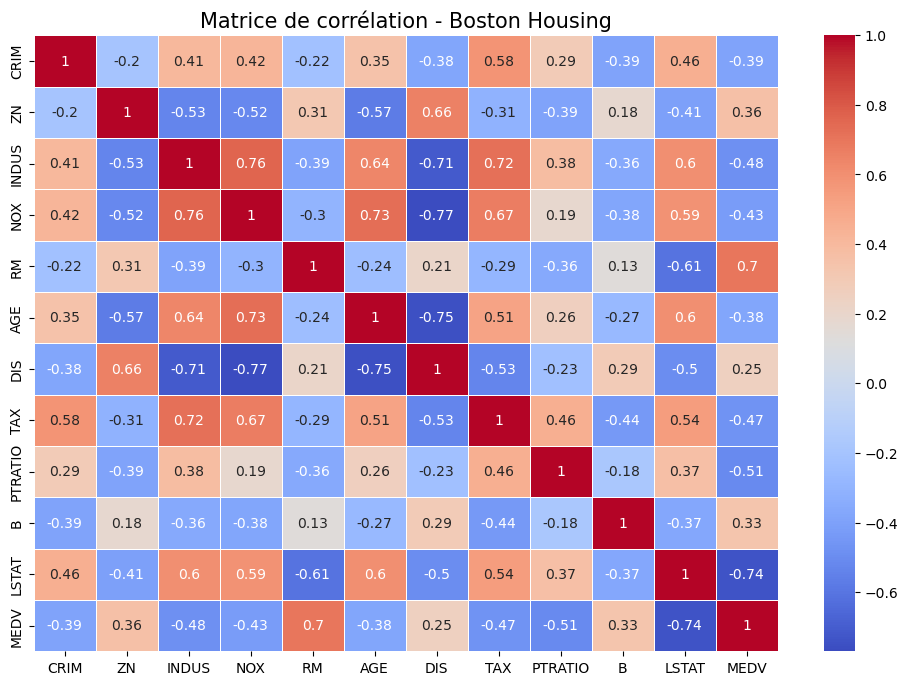

In [6]:
correlation_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(12, 8))
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation - Boston Housing', fontsize=15)
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_numeric = df.select_dtypes(include=['number'])
X = df_numeric.drop(columns=['MEDV'])
y = df_numeric['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modele = LinearRegression()
modele.fit(X_train, y_train)

print("L'algorithme s'est entraîné et a trouvé l'équation parfaite")

L'algorithme s'est entraîné et a trouvé l'équation parfaite


In [14]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
y_pred = modele.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Performances du modèle")
print(f"R2 (score de précision) : {r2:.3f} (soit {r2*100:.1f} %)")
print(f"MSE (erreur quadratique) : {mse:.2f}")
print(f"RMSE (marge d'erreur moyenne) : {rmse:.2f} milliers de $")
print(f"MAPE (marge d'erreur en %) : {mape:.2%}")

Performances du modèle
R2 (score de précision) : 0.631 (soit 63.1 %)
MSE (erreur quadratique) : 27.08
RMSE (marge d'erreur moyenne) : 5.20 milliers de $
MAPE (marge d'erreur en %) : 18.57%


poids des critères sur le prix


,critère,impact_financier
4,RM,4.823591
1,ZN,0.023392
9,B,0.012206
2,INDUS,0.002406
7,TAX,0.000667
5,AGE,-0.008582
0,CRIM,-0.085144
10,LSTAT,-0.513855
8,PTRATIO,-0.838392
6,DIS,-1.444047


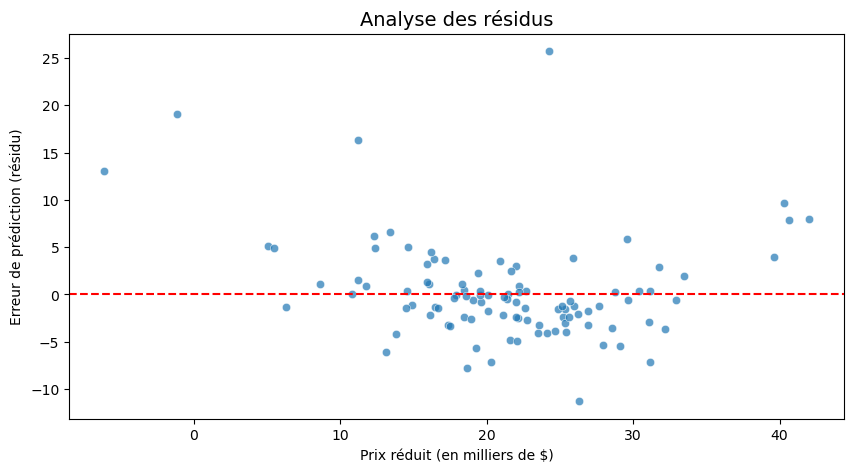

In [21]:
coefficients = pd.DataFrame({
    'critère': X.columns,
    'impact_financier': modele.coef_
}).sort_values(by='impact_financier', ascending=False)

print("poids des critères sur le prix")
display(coefficients)

residus = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residus, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Analyse des résidus', fontsize=14)
plt.xlabel('Prix réduit (en milliers de $)')
plt.ylabel('Erreur de prédiction (résidu)')
plt.show()

Ce modèle nous donne une base solide pour estimer le prix d'une maison, avec une marge d'erreur moyenne d'environ 18,5 %.

* Le nombre de pièces (`RM`) reste le critère numéro un pour faire grimper la valeur d'un bien.
* Une maison perd drastiquement de sa valeur si elle est située dans un quartier défavorisé (`LSTAT`) ou fortement pollué (`NOX`), peu importe sa taille.
* Notre modèle se débrouille très bien pour estimer les maisons classiques, mais il a tendance à sous-évaluer l'immobilier de luxe. Les biens d'exception ne suivent pas une logique strictement "linéaire".